## Importing Libraries

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
# Text Processing
import re
import nltk
import emoji
from nltk.stem import WordNetLemmatizer

In [3]:
# Download required NLTK resources
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from sklearn.utils.class_weight import compute_class_weight

In [5]:
# Machine Learning Models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [6]:
# Deep Learning Models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN, Bidirectional, GlobalAveragePooling1D, Dropout, LSTM

In [7]:
# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [8]:
# Model Deployment
import gradio as gr
from tensorflow.keras.models import load_model
import pickle

d:\Sentiment_Analysis\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [9]:
df = pd.read_csv('sentiment_data.csv', index_col=0)
# index_col=0 --> To avoid seeing the index column twice
df

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2
...,...,...
241921,crores paid neerav modi recovered congress lea...,0
241922,dear rss terrorist payal gawar modi killing pl...,0
241923,cover interaction forum left,1
241924,big project came india modi dream project happ...,1


## Exploratory Data Analysis

##### Chek null values.
##### Check the class distribution (Negative, Neutral, Positive).
##### Look at review lengths.
##### Visualize the most common words using WordClouds.
##### Check comments containing emojis.
##### Check special characters.

In [10]:
# Check Null Values
df.isna().sum()

Comment      217
Sentiment      0
dtype: int64

In [11]:
# Let's drop them
df.dropna(inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_7172\4173382935.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='Blues')


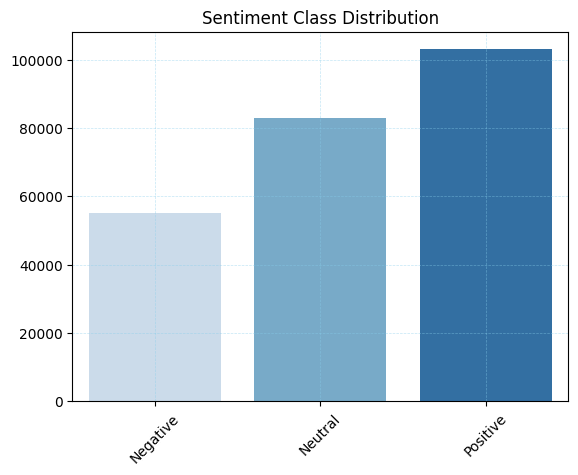

In [12]:
# Class Distribution
sns.countplot(x='Sentiment', data=df, palette='Blues')
plt.grid(linestyle='--', alpha=0.5, linewidth=0.5, color='skyblue')
plt.xticks([0,1,2], ['Negative', 'Neutral', 'Positive'], rotation=45)
plt.title('Sentiment Class Distribution')
plt.xlabel('')
plt.ylabel('')
plt.show()

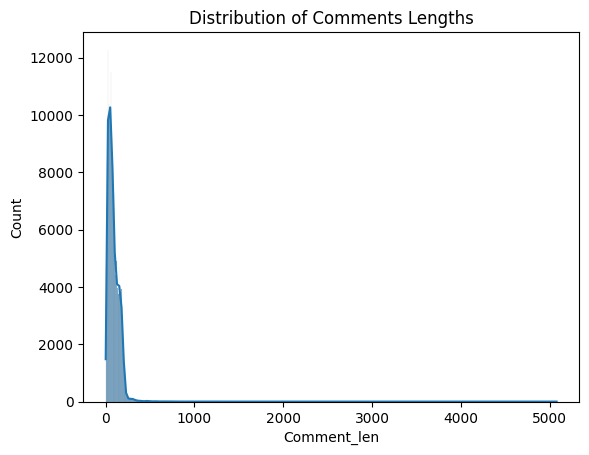

In [13]:
# Review the lengths of the comments
df['Comment_len'] = df['Comment'].apply(len)
sns.histplot(x='Comment_len', data=df, kde=True)
plt.title('Distribution of Comments Lengths')
plt.show()

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sentiment,240928.0,1.198985,0.785386,0.0,1.0,1.0,2.0,2.0
Comment_len,240928.0,87.661272,71.974148,1.0,41.0,72.0,124.0,5080.0


In [15]:
# Let's see how many comments that have length greater than or equal 1000
len(df[df['Comment_len'] >= 1000])

100

In [16]:
# Checking it's sentiment
df[df['Comment_len'] >= 1000]['Sentiment'].value_counts()

Sentiment
1    52
2    32
0    16
Name: count, dtype: int64

In [17]:
# WordCloud
positive_comments = " ".join(df[df["Sentiment"]==2]["Comment"])
negative_comments = " ".join(df[df["Sentiment"]==0]["Comment"])

wordcloud_pos = WordCloud(width=800, height=400, background_color="white").generate(positive_comments)
wordcloud_neg = WordCloud(width=800, height=400, background_color="black").generate(negative_comments)

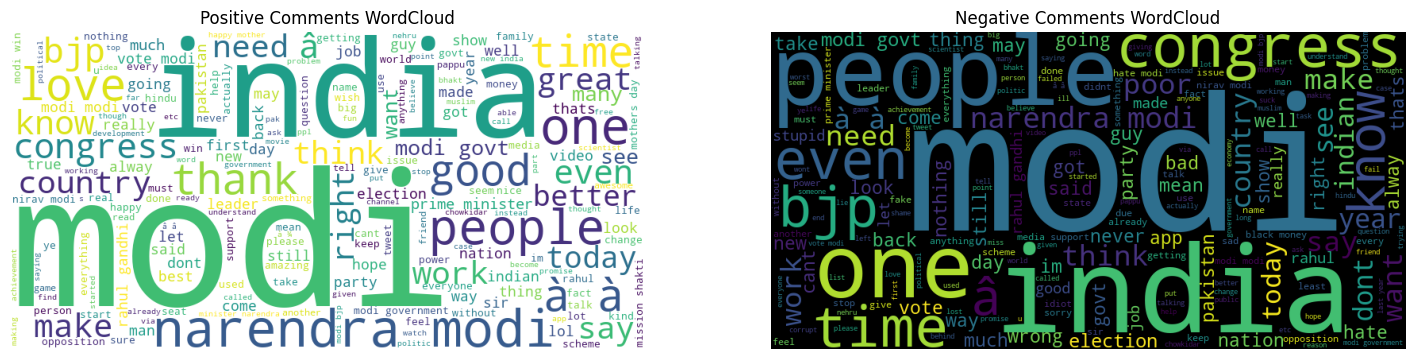

In [18]:
plt.figure(figsize=(18,9))
plt.subplot(1,2,1)
plt.imshow(wordcloud_pos)
plt.title("Positive Comments WordCloud")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wordcloud_neg)
plt.title("Negative Comments WordCloud")
plt.axis("off")
plt.show()


In [19]:
# Check the emojis
emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons [😀 → 🙏]
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs [🌀 → 🗿]
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols [🚀 → 🚿]
                           u"\U0001F1E0-\U0001F1FF"  # flags [🇦 → 🇿]
                           u"\U00002700-\U000027BF"  # Dingbats [✀ → ➿]
                           u"\U000024C2-\U0001F251"  # Enclosed characters [Ⓜ → 🉑]
                           "]+", flags=re.UNICODE)
# Find comments containing emojis and store them
df['emojis'] = df['Comment'].apply(lambda x: ''.join(emoji_pattern.findall(str(x))))

# Number of comments that have at least one emoji
num_comments_with_emojis = df['emojis'].apply(lambda x: len(x) > 0).sum()

print("\nNumber of comments with emojis:", num_comments_with_emojis)

# See some examples
print("\nSample emojis found:")
df[df['emojis'] != ''][['Comment', 'emojis']].sample(30)


Number of comments with emojis: 456

Sample emojis found:


,Comment,emojis
6992,thank listening love it♡♡♡,♡♡♡
59430,using app samsung last years found good good a...,😊
13899,trying test bio eventually get third degree nu...,
7169,thank great course always！,！
63555,image beginning time difference phone time edi...,😁✌
61939,great app love well thought ux thanks free mon...,😊
73566,love app think perfect needed time sadly job c...,❤❤
4383,solve rubiks cube faster ► please read comment...,►
52193,kind sad able choose put tree terraine app see...,💪
10858,im sleep good night everyone ♡,♡


## Data Preprocessing

##### Remove non-English words → keep only English letters and emojis.
##### Lemmatization → reduce words to their base form (e.g., running → run).
##### Convert emojis to words → map 🙂 → "smile", 🙁 → "sad", etc.
##### Tokenization → convert words into integer indices.
##### Padding → make all sequences the same length.
##### Train-test split → separate data for training and validation.
##### Feature Engineering → TF-IDF (for ML baselines) or Word2Vec/Embeddings (for DL models).

In [20]:
# Remove non-English words and keep the emojis

def remove_non_english(text):
    pattern = re.compile(
        r"[^A-Za-z\u2600-\u26FF\u2700-\u27BF\U0001F300-\U0001F5FF\U0001F600-\U0001F64F\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F900-\U0001F9FF ]+",
        flags=re.UNICODE
    )
    return pattern.sub("", text)

df["Cleaned_Comment"] = df["Comment"].apply(remove_non_english)

In [21]:
for _, row in df[df['emojis'] != ''].sample(10).iterrows():
    print('Before:', str(row['Comment']))
    print()
    print('After:', str(row['Cleaned_Comment']))
    print('-'*40)

Before: hermosa elección los mortales abian apreciado tan hermosa mujer elecciones culturales 🅻🅸🆅🅴 hopi sweeter sun hotter joonie cooler yoongy butter son unos de los mejores conciertos mañas se la las elecciones cinematográficas artísticas son brillantes referencias culturales europeas realmente interesantes ojalá la cultura europea se representara más menudo tan bellamente puedo dejar de decir oh esto es hermoso lo largo del video luz en serio el que se encargue de la iluminación genial

After: hermosa eleccin los mortales abian apreciado tan hermosa mujer elecciones culturales  hopi sweeter sun hotter joonie cooler yoongy butter son unos de los mejores conciertos maas se la las elecciones cinematogrficas artsticas son brillantes referencias culturales europeas realmente interesantes ojal la cultura europea se representara ms menudo tan bellamente puedo dejar de decir oh esto es hermoso lo largo del video luz en serio el que se encargue de la iluminacin genial
-----------------------

In [22]:
df = df[df['Cleaned_Comment'] != '']
df.head()

,Comment,Sentiment,Comment_len,emojis,Cleaned_Comment
0,lets forget apple pay required brand new iphon...,1,231,,lets forget apple pay required brand new iphon...
1,nz retailers don’t even contactless credit car...,0,113,,nz retailers dont even contactless credit card...
2,forever acknowledge channel help lessons ideas...,2,114,,forever acknowledge channel help lessons ideas...
3,whenever go place doesn’t take apple pay doesn...,0,328,,whenever go place doesnt take apple pay doesnt...
4,apple pay convenient secure easy use used kore...,2,93,,apple pay convenient secure easy use used kore...


In [23]:
# Lemmatization
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

df["Cleaned_Lemma_Comment"] = df["Cleaned_Comment"].apply(lemmatize_text)


In [24]:
for _, row in df.sample(10).iterrows():
    print('Before Lemmatization:', str(row['Cleaned_Comment']))
    print()
    print('After Lemmatization:', str(row['Cleaned_Lemma_Comment']))
    print('-'*40)

Before Lemmatization: phd ai say andrew best machine learningai educator ever seen field deeplearning specialization invaluable interested learner dl

After Lemmatization: phd ai say andrew best machine learningai educator ever seen field deeplearning specialization invaluable interested learner dl
----------------------------------------
Before Lemmatization: well official strep

After Lemmatization: well official strep
----------------------------------------
Before Lemmatization: understand people bring anti modi problem thatbut moment say replaced rahul gandhi lose respect towards person simply sold

After Lemmatization: understand people bring anti modi problem thatbut moment say replaced rahul gandhi lose respect towards person simply sold
----------------------------------------
Before Lemmatization: hi sir years experience infrastructure management want switch data science field prior programming experience ok switch technology learn want switch management role

After Lemmatiza

In [25]:
def clean_text(text):
    text = str(text)

    # Step 1: demojize first
    text = emoji.demojize(text)

    # Step 2: replace ":emoji_name:" with "space + emoji_name + space"
    text = re.sub(r':([a-zA-Z0-9_]+):', r' \1 ', text)

    # Step 3: remove non-ASCII chars (foreign text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Step 4: remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [26]:
df['Cleaned_Comment'] = df['Cleaned_Lemma_Comment'].apply(clean_text)

In [27]:
for _, row in df[df['emojis'] != ''].sample(10).iterrows():
    print('Before:', str(row['Cleaned_Lemma_Comment']))
    print()
    print('After:', str(row['Cleaned_Comment']))
    print('-'*40)

Before: paid subscription doesnt show manage subscription able end subscription😡

After: paid subscription doesnt show manage subscription able end subscription enraged_face
----------------------------------------
Before: 

After: 
----------------------------------------
Before: love app ❤ would however like could add something make app feel even polished peaceful instance animal wonder around forest healthier forest animal come could move tree add river worth premium good big group focus love store fact buy different tree grow get different sound music

After: love app red_heart would however like could add something make app feel even polished peaceful instance animal wonder around forest healthier forest animal come could move tree add river worth premium good big group focus love store fact buy different tree grow get different sound music
----------------------------------------
Before: great appi like way look like clock👍

After: great appi like way look like clock thumbs_up
--

In [28]:
df.tail()

,Comment,Sentiment,Comment_len,emojis,Cleaned_Comment,Cleaned_Lemma_Comment
241921,crores paid neerav modi recovered congress lea...,0,79,,crore paid neerav modi recovered congress lead...,crore paid neerav modi recovered congress lead...
241922,dear rss terrorist payal gawar modi killing pl...,0,223,,dear rss terrorist payal gawar modi killing pl...,dear rss terrorist payal gawar modi killing pl...
241923,cover interaction forum left,1,28,,cover interaction forum left,cover interaction forum left
241924,big project came india modi dream project happ...,1,58,,big project came india modi dream project happ...,big project came india modi dream project happ...
241925,ever listen like gurukul discipline maintained...,2,158,,ever listen like gurukul discipline maintained...,ever listen like gurukul discipline maintained...


## Splitting Dataset into X and y

In [29]:
X = df['Cleaned_Comment']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Models Training

### Machine Learning Models
#### Logistic Regression
 A linear model that works well for text classification with TF-IDF features.
#### Random Forest
 An ensemble method that builds multiple decision trees and averages their predictions.

### Logistic Regression

In [32]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=5000, C=10, penalty='l2', solver='saga', class_weight="balanced")
log_reg.fit(X_train_tfidf, y_train)

d:\Sentiment_Analysis\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [33]:
# Predictions
y_pred_lr = log_reg.predict(X_test_tfidf)

In [34]:
# Evaluation
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.74      0.72     11021
           1       0.75      0.81      0.78     16550
           2       0.86      0.78      0.82     20609

    accuracy                           0.78     48180
   macro avg       0.77      0.78      0.77     48180
weighted avg       0.79      0.78      0.78     48180



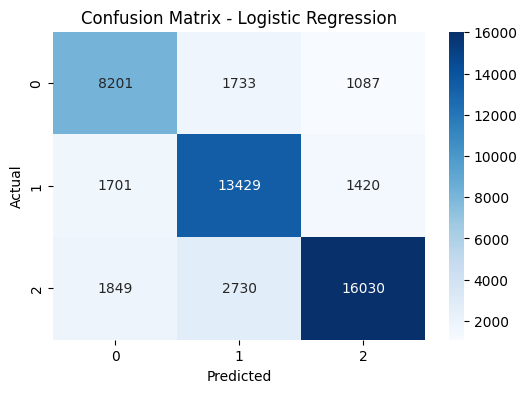

In [35]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## RandomForest

In [36]:
# model fitting
rf = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=300, max_depth=25,
                            min_samples_split=10, min_samples_leaf=4, class_weight='balanced')

rf.fit(X_train_tfidf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [37]:
# Predictions
y_pred_rf = rf.predict(X_test_tfidf)

In [38]:
# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.56      0.61     11021
           1       0.60      0.86      0.71     16550
           2       0.85      0.65      0.73     20609

    accuracy                           0.70     48180
   macro avg       0.71      0.69      0.69     48180
weighted avg       0.73      0.70      0.70     48180



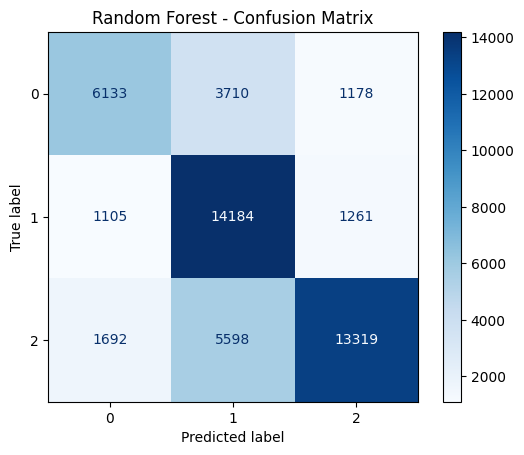

In [39]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest - Confusion Matrix")
plt.show()

##  Deep Learning Models
##### FNN (Feedforward Neural Network)
A fully connected network trained on embeddings of the text.
##### RNN (Recurrent Neural Network)
A sequence model that captures temporal dependencies in text.
##### Stacked RNN
Multiple RNN layers stacked together for learning complex sequence patterns.
##### BiRNN (Bidirectional RNN)
Processes the input sequence in both forward and backward directions to capture context from both sides.

### 1. FeedForward Neural Network

In [40]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [41]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_train_pad = pad_sequences(X_train_seq, maxlen=100)  

X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

In [42]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format {class_label: weight}
class_weights_dict = dict(zip(np.unique(y_train), class_weights))

print("Class Weights:", class_weights_dict)

Class Weights: {np.int64(0): np.float64(1.457195354323564), np.int64(1): np.float64(0.9703776435045317), np.int64(2): np.float64(0.7792874212997222)}


In [43]:
# --- Callbacks ---
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,          
    restore_best_weights=True
)

checkpoint_fnn = ModelCheckpoint(
    "best_fnn_model.h5",   
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

checkpoint_rnn = ModelCheckpoint(
    "best_rnn_model.h5",   
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [44]:
input_dim = 5000
output_dim=128
input_length=100

In [45]:
model = Sequential([
    Embedding(input_dim=input_dim, output_dim=output_dim, input_length=input_length),
    GlobalAveragePooling1D(),  # flatten embeddings
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

d:\Sentiment_Analysis\env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = model.fit(
    X_train_pad,
    y_train,   
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=64,
    class_weight=class_weights_dict,   
    verbose=1,
    callbacks=[early_stopping, checkpoint_fnn]
)

Epoch 1/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4696 - loss: 1.0183
Epoch 1: val_loss improved from None to 0.65565, saving model to best_fnn_model.h5



Epoch 1: finished saving model to best_fnn_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.5766 - loss: 0.9042 - val_accuracy: 0.7627 - val_loss: 0.6556
Epoch 2/15
3008/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7451 - loss: 0.6641
Epoch 2: val_loss improved from 0.65565 to 0.56384, saving model to best_fnn_model.h5



Epoch 2: finished saving model to best_fnn_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.7548 - loss: 0.6420 - val_accuracy: 0.7799 - val_loss: 0.5638
Epoch 3/15
3009/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7797 - loss: 0.5852
Epoch 3: val_loss improved from 0.56384 to 0.53068, saving model to best_fnn_model.h5



Epoch 3: finished saving model to best_fnn_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.7773 - loss: 0.5872 - val_accuracy: 0.7943 - val_loss: 0.5307
Epoch 4/15
3011/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7859 - loss: 0.5648
Epoch 4: val_loss improved from 0.53068 to 0.51630, saving model to best_fnn_model.h5



Epoch 4: finished saving model to best_fnn_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.7878 - loss: 0.5613 - val_accuracy: 0.8043 - val_loss: 0.5163
Epoch 5/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7951 - loss: 0.5446
Epoch 5: val_loss did not improve from 0.51630
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.7954 - loss: 0.5444 - val_accuracy: 0.7928 - val_loss: 0.5555
Epoch 6/15
3007/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7995 - loss: 0.5339
Epoch 6: val_loss did not improve from 0.51630
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.7981 - loss: 0.5378 - val_accuracy: 0.7862 - val_loss: 0.5553
Epoch 7/15
3009/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8020 - loss: 0.5249
Epoch 7: val_loss improved from 0.51630 to 0.50415, saving model to best_fnn_model.h5



Epoch 7: finished saving model to best_fnn_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.8029 - loss: 0.5252 - val_accuracy: 0.8133 - val_loss: 0.5042
Epoch 8/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8089 - loss: 0.5142
Epoch 8: val_loss did not improve from 0.50415
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.8089 - loss: 0.5126 - val_accuracy: 0.7622 - val_loss: 0.5835
Epoch 9/15
3009/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8098 - loss: 0.5092
Epoch 9: val_loss did not improve from 0.50415
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.8103 - loss: 0.5089 - val_accuracy: 0.8102 - val_loss: 0.5082
Epoch 10/15
3008/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8167 - loss: 0.4951
Epoch 10: val_loss improved from 0.50415 to 0.49711, saving model to best_fnn_model.h5



Epoch 10: finished saving model to best_fnn_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.8136 - loss: 0.5013 - val_accuracy: 0.8149 - val_loss: 0.4971
Epoch 11/15
3009/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8168 - loss: 0.4944
Epoch 11: val_loss did not improve from 0.49711
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - accuracy: 0.8163 - loss: 0.4949 - val_accuracy: 0.8134 - val_loss: 0.5030
Epoch 12/15
3011/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8232 - loss: 0.4772
Epoch 12: val_loss did not improve from 0.49711
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.8206 - loss: 0.4842 - val_accuracy: 0.8125 - val_loss: 0.5077
Epoch 13/15
3008/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8226 - loss: 0.4812
Epoch 13: val_loss improved from 0.49711 to 0.49553, saving model to best_fnn_model.h5



Epoch 13: finished saving model to best_fnn_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.8233 - loss: 0.4791 - val_accuracy: 0.8217 - val_loss: 0.4955
Epoch 14/15
3010/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8266 - loss: 0.4712
Epoch 14: val_loss did not improve from 0.49553
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - accuracy: 0.8245 - loss: 0.4755 - val_accuracy: 0.8182 - val_loss: 0.5017
Epoch 15/15
3009/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8299 - loss: 0.4633
Epoch 15: val_loss did not improve from 0.49553
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.8280 - loss: 0.4673 - val_accuracy: 0.8079 - val_loss: 0.5128


In [47]:
# Predict probabilities
y_pred_probs = model.predict(X_test_pad)

# Convert probabilities to class labels
y_pred_FNN = np.argmax(y_pred_probs, axis=1)

1506/1506 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [48]:
# Model Evaluation
print(classification_report(y_test, y_pred_FNN))

              precision    recall  f1-score   support

           0       0.76      0.77      0.76     11021
           1       0.77      0.86      0.82     16550
           2       0.90      0.82      0.86     20609

    accuracy                           0.82     48180
   macro avg       0.81      0.82      0.81     48180
weighted avg       0.83      0.82      0.82     48180



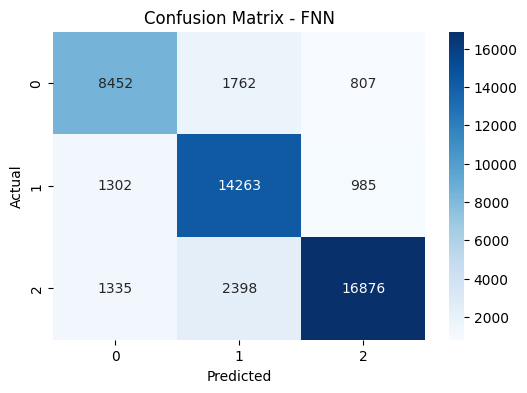

In [49]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_FNN)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - FNN")
plt.show()

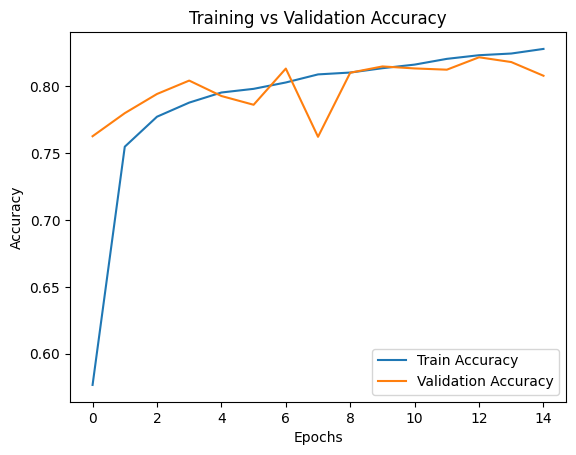

In [50]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

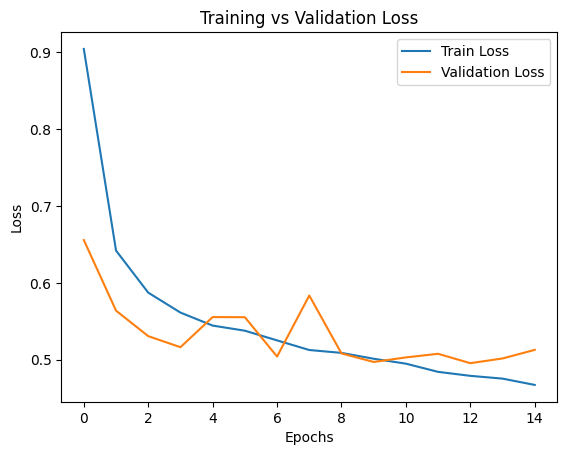

In [51]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### 2.Stacked RNN

In [52]:
model = Sequential()
model.add(Embedding(input_dim=input_dim, output_dim=output_dim, input_length=input_length))
model.add(SimpleRNN(64, return_sequences=True))   
model.add(Dropout(0.3))
model.add(SimpleRNN(32))                           

# Output layer for 3-class classification
model.add(Dense(3, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

d:\Sentiment_Analysis\env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = model.fit(
    X_train_pad,
    y_train,   
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=64,
    class_weight=class_weights_dict,   
    verbose=1,
    callbacks=[early_stopping, checkpoint_rnn]
)

Epoch 1/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6452 - loss: 0.8160
Epoch 1: val_loss improved from None to 0.75228, saving model to best_rnn_model.h5



Epoch 1: finished saving model to best_rnn_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 213s 69ms/step - accuracy: 0.7267 - loss: 0.7034 - val_accuracy: 0.7083 - val_loss: 0.7523
Epoch 2/15
3011/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7881 - loss: 0.5872
Epoch 2: val_loss improved from 0.75228 to 0.55812, saving model to best_rnn_model.h5



Epoch 2: finished saving model to best_rnn_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 190s 63ms/step - accuracy: 0.7913 - loss: 0.5787 - val_accuracy: 0.7977 - val_loss: 0.5581
Epoch 3/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8070 - loss: 0.5236
Epoch 3: val_loss improved from 0.55812 to 0.55204, saving model to best_rnn_model.h5



Epoch 3: finished saving model to best_rnn_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 175s 58ms/step - accuracy: 0.8056 - loss: 0.5300 - val_accuracy: 0.8010 - val_loss: 0.5520
Epoch 4/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8099 - loss: 0.5142
Epoch 4: val_loss improved from 0.55204 to 0.54573, saving model to best_rnn_model.h5



Epoch 4: finished saving model to best_rnn_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 200s 66ms/step - accuracy: 0.8157 - loss: 0.5025 - val_accuracy: 0.8046 - val_loss: 0.5457
Epoch 5/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8343 - loss: 0.4534
Epoch 5: val_loss did not improve from 0.54573
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 200s 66ms/step - accuracy: 0.8294 - loss: 0.4655 - val_accuracy: 0.7748 - val_loss: 0.6142


In [54]:
# Predict probabilities
y_pred_probs = model.predict(X_test_pad)

# Convert probabilities to class labels
y_pred_RNN = np.argmax(y_pred_probs, axis=1)

1506/1506 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step


In [55]:
print(classification_report(y_test, y_pred_RNN))

              precision    recall  f1-score   support

           0       0.58      0.80      0.67     11021
           1       0.68      0.73      0.70     16550
           2       0.87      0.64      0.74     20609

    accuracy                           0.71     48180
   macro avg       0.71      0.72      0.70     48180
weighted avg       0.74      0.71      0.71     48180



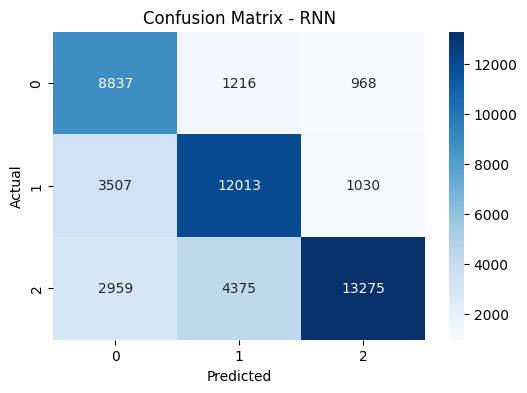

In [56]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_RNN)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RNN")
plt.show()

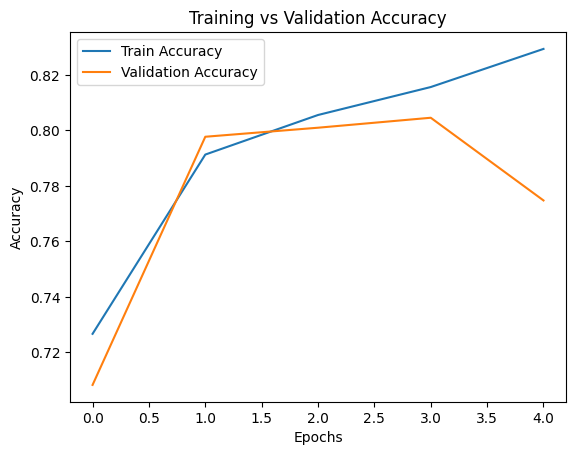

In [57]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

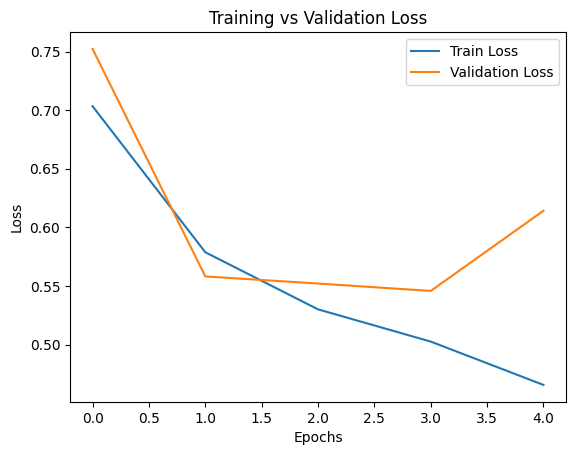

In [58]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### 3. Stacked LSTM

In [59]:
model = Sequential()
model.add(Embedding(input_dim=input_dim, output_dim=output_dim, input_length=input_length))

model.add(LSTM(128, return_sequences=True))   # first LSTM returns sequences
model.add(Dropout(0.3))
model.add(LSTM(64))                           # second LSTM
model.add(Dropout(0.3))

model.add(Dense(3, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

d:\Sentiment_Analysis\env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [60]:
checkpoint_lstm = ModelCheckpoint(
    "best_lstm_model.h5",   
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [61]:
history = model.fit(
    X_train_pad,
    y_train,   
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=64,
    class_weight=class_weights_dict,   
    verbose=1,
    callbacks=[early_stopping, checkpoint_lstm]
) 

Epoch 1/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7103 - loss: 0.7013
Epoch 1: val_loss improved from None to 0.50451, saving model to best_lstm_model.h5



Epoch 1: finished saving model to best_lstm_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 3675s 1s/step - accuracy: 0.7742 - loss: 0.5915 - val_accuracy: 0.8111 - val_loss: 0.5045
Epoch 2/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.8189 - loss: 0.4906
Epoch 2: val_loss improved from 0.50451 to 0.47730, saving model to best_lstm_model.h5



Epoch 2: finished saving model to best_lstm_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 619s 205ms/step - accuracy: 0.8206 - loss: 0.4891 - val_accuracy: 0.8257 - val_loss: 0.4773
Epoch 3/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8364 - loss: 0.4477
Epoch 3: val_loss improved from 0.47730 to 0.46865, saving model to best_lstm_model.h5



Epoch 3: finished saving model to best_lstm_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 722s 240ms/step - accuracy: 0.8359 - loss: 0.4500 - val_accuracy: 0.8291 - val_loss: 0.4687
Epoch 4/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8509 - loss: 0.4099
Epoch 4: val_loss improved from 0.46865 to 0.46721, saving model to best_lstm_model.h5



Epoch 4: finished saving model to best_lstm_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 653s 210ms/step - accuracy: 0.8486 - loss: 0.4165 - val_accuracy: 0.8309 - val_loss: 0.4672
Epoch 5/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8632 - loss: 0.3731
Epoch 5: val_loss did not improve from 0.46721
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 714s 237ms/step - accuracy: 0.8595 - loss: 0.3828 - val_accuracy: 0.8328 - val_loss: 0.4751
Epoch 6/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8742 - loss: 0.3422
Epoch 6: val_loss did not improve from 0.46721
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 660s 219ms/step - accuracy: 0.8710 - loss: 0.3490 - val_accuracy: 0.8292 - val_loss: 0.5013
Epoch 7/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8875 - loss: 0.3047
Epoch 7: val_loss did not improve from 0.46721
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 726s 241ms/step - accuracy: 0.8832 - loss: 0.3160 - val_accuracy: 0.8291 - val_loss: 0.5099
Epoch 8/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0

In [62]:
# Predict probabilities
y_pred_probs = model.predict(X_test_pad) 

# Convert probabilities to class labels
y_pred_LSTM = np.argmax(y_pred_probs, axis=1)

1506/1506 ━━━━━━━━━━━━━━━━━━━━ 80s 53ms/step


In [63]:
print(classification_report(y_test, y_pred_LSTM))

              precision    recall  f1-score   support

           0       0.74      0.81      0.78     11021
           1       0.82      0.84      0.83     16550
           2       0.90      0.83      0.87     20609

    accuracy                           0.83     48180
   macro avg       0.82      0.83      0.82     48180
weighted avg       0.84      0.83      0.83     48180



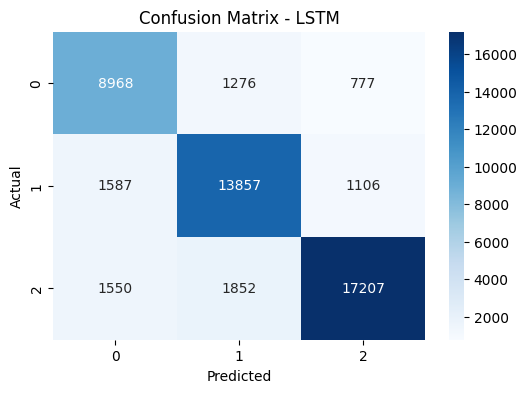

In [64]:

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_LSTM)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LSTM")
plt.show()

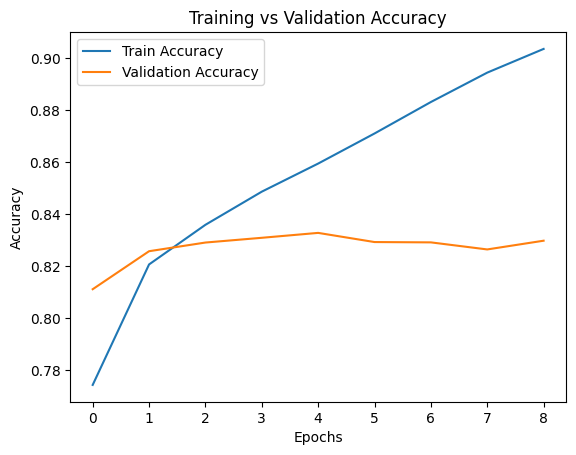

In [65]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

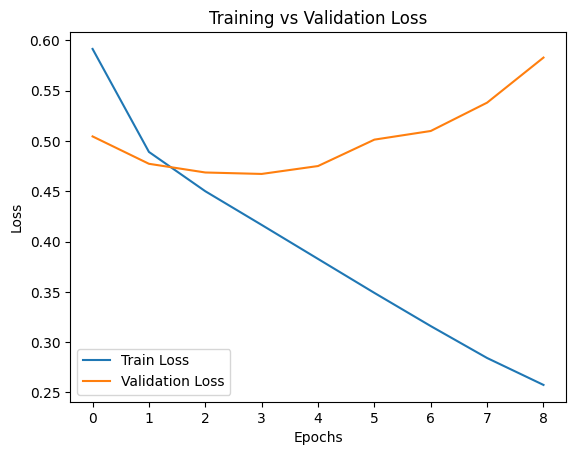

In [66]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### 4. BiLSTM

In [67]:
model = Sequential()
model.add(Embedding(input_dim=input_dim, output_dim=output_dim, input_length=input_length))

# First BiLSTM (returns sequences so the next BiLSTM can process)
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.3))

# Second BiLSTM
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))

model.add(Dense(3, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

d:\Sentiment_Analysis\env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [68]:
checkpoint_bilstm = ModelCheckpoint(
    "best_bilstm_model.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [69]:
history = model.fit(
    X_train_pad,
    y_train,   
    validation_data=(X_test_pad, y_test), 
    epochs=15,
    batch_size=64,
    class_weight=class_weights_dict,   
    verbose=1,
    callbacks=[early_stopping, checkpoint_bilstm]
)

Epoch 1/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.7170 - loss: 0.6893
Epoch 1: val_loss improved from None to 0.51287, saving model to best_bilstm_model.h5



Epoch 1: finished saving model to best_bilstm_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 1161s 382ms/step - accuracy: 0.7766 - loss: 0.5875 - val_accuracy: 0.8105 - val_loss: 0.5129
Epoch 2/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.8196 - loss: 0.4910
Epoch 2: val_loss improved from 0.51287 to 0.48373, saving model to best_bilstm_model.h5



Epoch 2: finished saving model to best_bilstm_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 1217s 404ms/step - accuracy: 0.8216 - loss: 0.4892 - val_accuracy: 0.8201 - val_loss: 0.4837
Epoch 3/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.8393 - loss: 0.4416
Epoch 3: val_loss improved from 0.48373 to 0.47638, saving model to best_bilstm_model.h5



Epoch 3: finished saving model to best_bilstm_model.h5
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 1224s 406ms/step - accuracy: 0.8375 - loss: 0.4482 - val_accuracy: 0.8298 - val_loss: 0.4764
Epoch 4/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.8539 - loss: 0.4030
Epoch 4: val_loss did not improve from 0.47638
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 1006s 334ms/step - accuracy: 0.8498 - loss: 0.4129 - val_accuracy: 0.8282 - val_loss: 0.4834
Epoch 5/15
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.8652 - loss: 0.3706
Epoch 5: val_loss did not improve from 0.47638
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 1022s 339ms/step - accuracy: 0.8617 - loss: 0.3797 - val_accuracy: 0.8308 - val_loss: 0.4797


In [70]:
# Predict class probabilities
y_pred_probs = model.predict(X_test_pad)

# Convert probabilities to class labels
y_pred_BiLSTM = np.argmax(y_pred_probs, axis=1)

1506/1506 ━━━━━━━━━━━━━━━━━━━━ 93s 62ms/step


Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75     11021
           1       0.77      0.84      0.80     16550
           2       0.91      0.79      0.85     20609

    accuracy                           0.81     48180
   macro avg       0.80      0.81      0.80     48180
weighted avg       0.82      0.81      0.81     48180



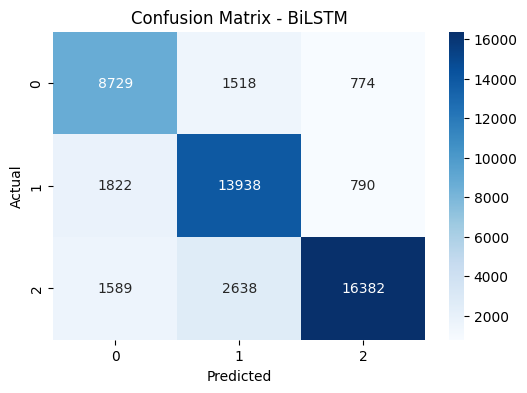

In [71]:
print("Classification Report:")
print(classification_report(y_test, y_pred_BiLSTM))

cm = confusion_matrix(y_test, y_pred_BiLSTM)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test)
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BiLSTM")
plt.show()

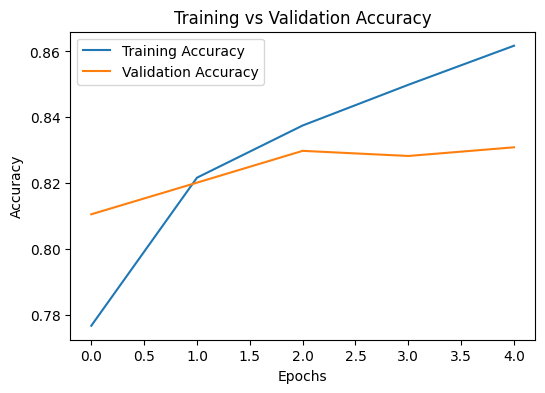

In [72]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

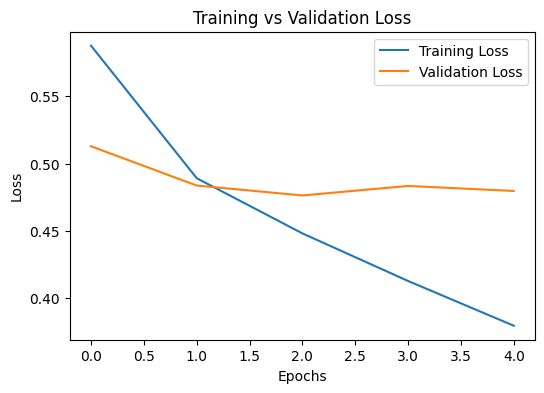

In [73]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()